# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
R = 1.
r = 0.6

NGSOLVE = True

lc = 0.6

from cases.open_space.ngsolve_geometries import CleanCircle, AnularDomain, Regions
# mesh = AnularDomain(R=R, r=r, verbosity=0, lc=lc)
mesh = CleanCircle(R=R, verbosity=0, lc=lc)


In [2]:
mesh.n_triangles

24

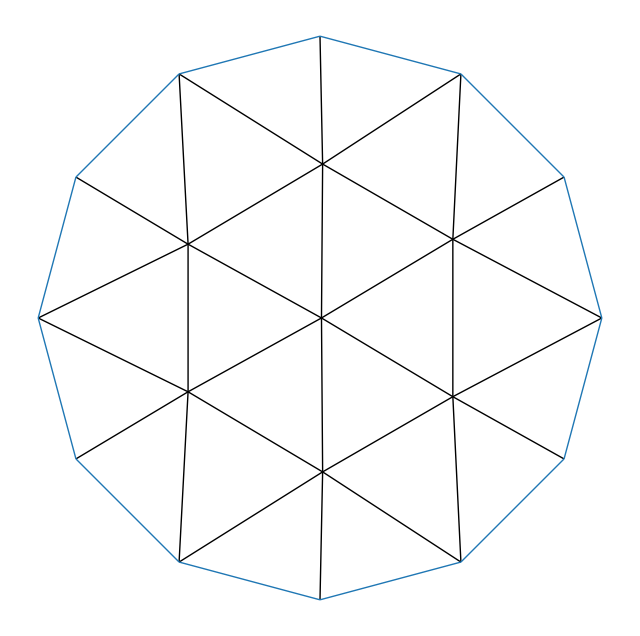

In [3]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [4]:
list(Regions)

[<Regions.OMEGA: 'Omega'>,
 <Regions.SIGMA: 'Sigma'>,
 <Regions.d_Omega: 'd_Omega'>]

In [5]:
mesh.curve_region(Regions.SIGMA, radius=R)
#mesh.curve_region(Regions.d_Omega, radius=r)


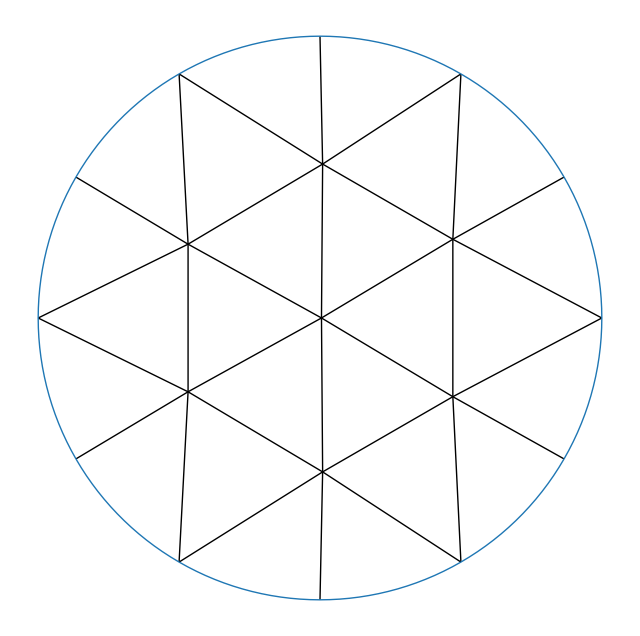

In [6]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [7]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [8]:
import numpy as np
data = {"d_inc": np.array([-1., 0.])}
# boundary_conditions = {Regions.SIGMA: NtDBC(truncating_radius=R, data=None), Regions.d_Omega: DirichletBC(data=data)}
boundary_conditions = {Regions.SIGMA: DirichletBC(data=data),}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [9]:
from trefftz.dg.serial_fluxes import UltraWeakFlux, DirichletFlux


as well as specific ones (for a circular NtD map):

In [10]:
#from cases.open_space.serial_kernels import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [11]:
from trefftz.dg.assemblers import SerialNumerics
NtD_modes = 5
a = 0.5
b = 0.5
d1 = 0.5
d2 = 0.5
# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal_circle(R=R, d_2=d2, data=None)},
#                           nonlocal_boundary_kernels={NtDBC: NtDNonLocal_circle(d_2=d2, NtD_modes=5, data = None)})
numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data)},
                          nonlocal_boundary_kernels={})

We should also choose a local basis

In [12]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
Ntheta = 11
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, k=k, N_theta=Ntheta)

and an assembler:

In [13]:
basis.N_DOF

264

In [14]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [15]:
assembler._regions_RHS_term

[<Regions.SIGMA: 'Sigma'>]

so we can set the problem:

In [16]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [17]:
A = P.assemble_LHS()

Interior: 100%|██████████| 30/30 [00:00<00:00, 34.83edge/s]


assembling local operators
region: Sigma


100%|██████████| 12/12 [00:01<00:00,  7.52edge/s]

assembling non-local operators


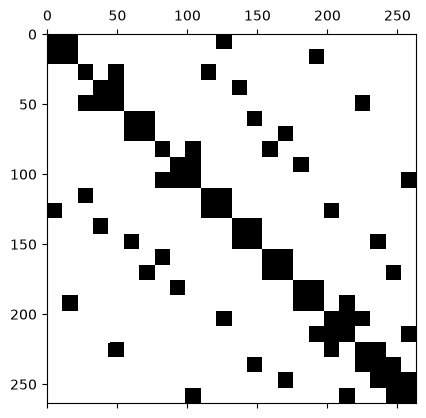

In [18]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [19]:
b = P.assemble_RHS()

region=<Regions.SIGMA: 'Sigma'>, value=np.complex128(-0.38899053721502225-0.5239077220999475j)
region=<Regions.SIGMA: 'Sigma'>, value=np.complex128(-0.17422206707350238+0.1132648641501468j)
region=<Regions.SIGMA: 'Sigma'>, value=np.complex128(0.1038582631975688+0.20383065085969426j)
region=<Regions.SIGMA: 'Sigma'>, value=np.complex128(0.22287117081995905+0.6888508496824894j)
region=<Regions.SIGMA: 'Sigma'>, value=np.complex128(1.2848139415000857+0.3278411513201309j)
region=<Regions.SIGMA: 'Sigma'>, value=np.complex128(-0.08609130301331991+0.03437553659829917j)
region=<Regions.SIGMA: 'Sigma'>, value=np.complex128(-1.7092539577885515+1.371103907621691j)
region=<Regions.SIGMA: 'Sigma'>, value=np.complex128(-0.7704673991686305-4.272829700492181j)
region=<Regions.SIGMA: 'Sigma'>, value=np.complex128(-0.5274306221239167+4.549903014714558j)
region=<Regions.SIGMA: 'Sigma'>, value=np.complex128(1.1491432728157154+1.5452720725673594j)
region=<Regions.SIGMA: 'Sigma'>, value=np.complex128(0.409929

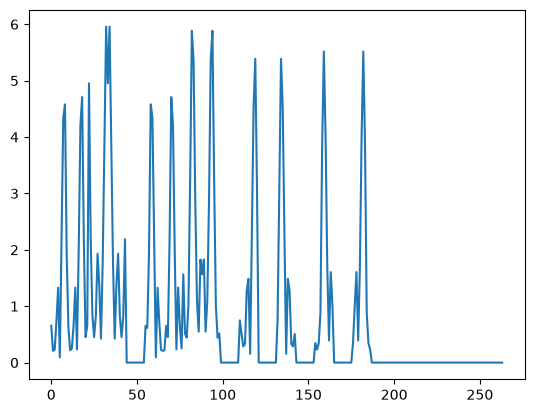

In [20]:
import numpy as np 
plt.plot(np.abs(b))

In [21]:
P.solve()

In [22]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[-8.95600467e-02-0.03808529j, -5.93267915e-02-0.08909264j,
        -8.68422550e-02-0.09336018j, -9.41450594e-02+0.14319702j,
        -5.81244591e-02-0.26197195j,  1.57382590e-01-0.68123807j,
         1.95676861e-01+0.54882209j,  1.23741526e-01+0.12659352j,
        -7.15587822e-03+0.1117099j , -1.70349807e-02-0.09229704j,
        -9.09853308e-02-0.01542846j],
       [-6.44696092e-02+0.0396745j , -8.21731011e-02+0.02527369j,
        -3.48768893e-03+0.10146546j, -2.63317628e-02-0.12703223j,
         1.31403344e-01-0.15933243j,  2.02235082e-01-0.59555j   ,
         1.47163360e-01+0.61944324j, -3.10078814e-02+0.19781569j,
        -7.37057975e-02-0.08349098j, -4.23327048e-02+0.06916632j,
        -2.78323753e-02+0.0672373j ],
       [ 5.50012424e-02-0.06393282j, -1.50101291e-02-0.07701362j,
         3.07633015e-02-0.07553171j,  9.95436281e-02-0.0438561j ,
         1.49097788e-01-0.11831046j, -5.81322654e-01-0.20624854j,
        -4.05903402e-01+0.50641481j, -1.40678542e-01+0.16456774j,


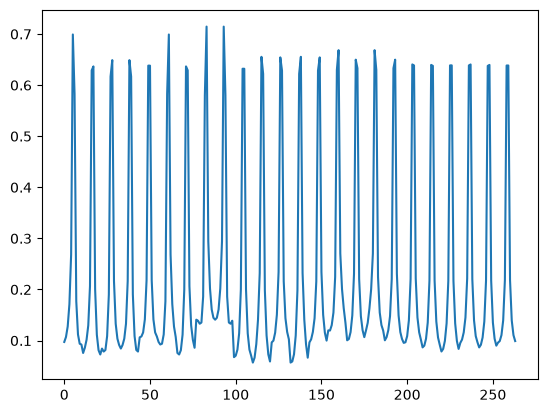

In [23]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [24]:
import numpy as np
N = 200
# rs = np.linspace(r, R, N)
rs = np.linspace(0, R, N)

theta = np.linspace(0, 2*np.pi, N)
Rs, Theta = np.meshgrid(rs, theta)
X = Rs*np.cos(Theta)
Y = Rs*np.sin(Theta)
x = X.ravel()
y = Y.ravel() 
z = P.u_h(x, y)

(np.float64(-1.0945934345764872),
 np.float64(1.0997425445036424),
 np.float64(-1.0944382655957148),
 np.float64(1.0998977134844148))

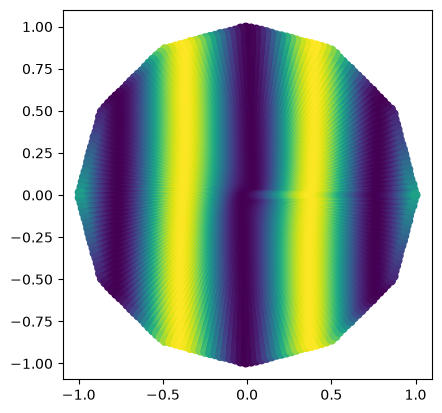

In [25]:
import matplotlib.pyplot as plt
plt.scatter(x,y,c=np.real(z),cmap="viridis")
plt.axis("square")